# Audio Emotion Recognition (ES) — Notebook final optimizado (RTX 3060)
Este notebook entrena un modelo **AST (Audio Spectrogram Transformer)** para clasificación de emociones usando `manifest_es.csv`.

Incluye:
- Split **por speaker** con `StratifiedGroupKFold`
- Balanceo con `WeightedRandomSampler`
- Augmentations ligeras (gain + time shift)
- Entrenamiento con **AMP**, gradient accumulation y scheduler
- Guardado del **mejor checkpoint por F1 macro**
- Evaluación final en test + matriz de confusión

> Si te da algún error de rutas (Windows), revisa la celda **Config** (DATA_ROOT).

In [1]:
import os, math, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torchaudio
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

from transformers import AutoFeatureExtractor, ASTForAudioClassification, get_cosine_schedule_with_warmup

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| torch:", torch.__version__)

# Optimizaciones (no cambian datos, solo rendimiento/estabilidad)
if device == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception as e:
        print("matmul_precision not available:", e)

device: cuda | torch: 2.7.1+cu118


## 1) Configuración del experimento

Definimos:
- Ruta del *manifest* (`manifest_es.csv`)
- Modelo base (AST preentrenado)
- Carpeta de salida y checkpoint del mejor modelo

Además, configuramos parámetros clave:
- `TARGET_SR` (resample a 16 kHz)
- `MAX_SECONDS` (recorte/padding a duración fija)
- Parámetros del DataLoader y uso de GPU/VRAM

In [2]:
# Ruta relativa: multimodal-emocion/notebooks -> ../data/audio/manifest_es.csv
MANIFEST_PATH = r"../data/audio/manifest_es.csv"

MODEL_NAME = "MIT/ast-finetuned-audioset-10-10-0.4593"

OUT_DIR = "runs_audio_ast_es_vram_max"
os.makedirs(OUT_DIR, exist_ok=True)
best_path = os.path.join(OUT_DIR, "best_ast_es.pt")

# Audio (misma data; si tus audios son >5s, aumentar MAX_SECONDS cambia el recorte/pad)
TARGET_SR = 16000
MAX_SECONDS = 5.0
TRAIN_AUGMENT = True

# Dataloader
NUM_WORKERS = 0      # Windows estable
PIN_MEMORY = True

# Entrenamiento
AUTO_TUNE_BATCH = True           # 👈 llena VRAM subiendo batch automáticamente
CANDIDATE_BATCHES = [8, 12, 16, 24, 32]  # intentos (depende de tu VRAM/longitud)
GRAD_ACCUM = 1                   # con batch grande, no hace falta acumular
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10
PATIENCE = 5

# Anti-overfitting (clave en tu caso)
EPOCHS_PHASE1 = 5       # freeze backbone
EPOCHS_PHASE2 = 8       # fase 2 más corta
LR_PHASE1 = 2e-4
LR_PHASE2 = 1e-5        # LR más bajo para no “romper” generalización
LABEL_SMOOTHING = 0.10  # 👈 reduce overfitting

print("saving best to:", best_path)

saving best to: runs_audio_ast_es_vram_max\best_ast_es.pt


## 2) Cargar manifest y preparar etiquetas

Leemos el CSV con las rutas de audio y sus etiquetas, normalizamos los textos y filtramos a las emociones permitidas.  
Creamos el mapeo `label ↔ id` para entrenar el clasificador y añadimos la columna numérica `y`.

In [3]:
df = pd.read_csv(MANIFEST_PATH)

df["label"] = df["label"].astype(str).str.lower().str.strip()
df["speaker"] = df["speaker"].astype(str)

allowed = ["anger","disgust","fear","joy","neutral","sadness"]
df = df[df["label"].isin(allowed)].reset_index(drop=True)

labels = sorted(df["label"].unique())
label2id = {lab:i for i,lab in enumerate(labels)}
id2label = {i:lab for lab,i in label2id.items()}
df["y"] = df["label"].map(label2id).astype(int)

print("rows:", len(df), "| speakers:", df["speaker"].nunique())
print("labels:", labels)
print(df["label"].value_counts())
df.head()

rows: 2738 | speakers: 273
labels: ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness']
label
disgust    457
fear       457
sadness    457
anger      456
joy        456
neutral    455
Name: count, dtype: int64


,path,label,dataset,speaker,split,utt_id,level,lang,y
0,C:\Users\Rafa\Downloads\proyecto-ia-20260212T1...,anger,mesd_es,mesd_C_A,all,Anger_C_A_abajo,NaN,NaN,0
1,C:\Users\Rafa\Downloads\proyecto-ia-20260212T1...,anger,mesd_es,mesd_C_A,all,Anger_C_A_adios,NaN,NaN,0
2,C:\Users\Rafa\Downloads\proyecto-ia-20260212T1...,anger,mesd_es,mesd_C_A,all,Anger_C_A_antes,NaN,NaN,0
3,C:\Users\Rafa\Downloads\proyecto-ia-20260212T1...,anger,mesd_es,mesd_C_A,all,Anger_C_A_arriba,NaN,NaN,0
4,C:\Users\Rafa\Downloads\proyecto-ia-20260212T1...,anger,mesd_es,mesd_C_A,all,Anger_C_A_ayer,NaN,NaN,0


## 3) Split train/val/test por *speaker* (sin fuga de identidad)

Dividimos el dataset usando `StratifiedGroupKFold`:
- **Estratificado** por clase (mantener proporción de emociones)
- **Agrupado** por `speaker` (el mismo hablante no aparece en train y test)

Esto evita “hacer trampa” aprendiendo la voz del hablante en lugar de la emoción.

In [4]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
splits = list(sgkf.split(df, df["y"], groups=df["speaker"]))

test_idx = splits[0][1]
trainval_idx = splits[0][0]

trainval_df = df.iloc[trainval_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

splits2 = list(sgkf.split(trainval_df, trainval_df["y"], groups=trainval_df["speaker"]))
val_idx = splits2[0][1]
train_idx = splits2[0][0]

train_df = trainval_df.iloc[train_idx].reset_index(drop=True)
val_df = trainval_df.iloc[val_idx].reset_index(drop=True)

print("train/val/test:", len(train_df), len(val_df), len(test_df))
print("speaker overlap train/val:", len(set(train_df.speaker) & set(val_df.speaker)))
print("speaker overlap train/test:", len(set(train_df.speaker) & set(test_df.speaker)))
print("speaker overlap val/test:", len(set(val_df.speaker) & set(test_df.speaker)))

train/val/test: 1775 413 550
speaker overlap train/val: 0
speaker overlap train/test: 0
speaker overlap val/test: 0


## 4) Preprocesado de audio (mono, resample, pad/trim)

Definimos funciones auxiliares para estandarizar el audio:
- Convertir a **mono**
- **Re-muestrear** a 16 kHz
- **Recortar o rellenar** a una longitud fija (`MAX_SECONDS`)

Así todos los ejemplos tienen el mismo formato de entrada para AST.

In [5]:
def _to_mono(waveform: torch.Tensor) -> torch.Tensor:
    if waveform.dim() == 2 and waveform.size(0) > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    return waveform

def _resample_if_needed(waveform: torch.Tensor, sr: int, target_sr: int) -> torch.Tensor:
    if sr != target_sr:
        waveform = torchaudio.functional.resample(waveform, sr, target_sr)
    return waveform

def _pad_or_trim(waveform: torch.Tensor, target_len: int) -> torch.Tensor:
    n = waveform.size(-1)
    if n == target_len:
        return waveform
    if n > target_len:
        return waveform[..., :target_len]
    return torch.nn.functional.pad(waveform, (0, target_len - n))

def _augment(waveform: torch.Tensor) -> torch.Tensor:
    # gain fuerte
    if np.random.rand() < 0.7:
        waveform = waveform * np.random.uniform(0.7, 1.3)
    # shift más fuerte
    if np.random.rand() < 0.7:
        max_shift = int(0.08 * waveform.size(-1))  # 8%
        shift = np.random.randint(-max_shift, max_shift + 1)
        waveform = torch.roll(waveform, shifts=shift, dims=-1)
    return torch.clamp(waveform, -1.0, 1.0)

class EmotionAudioDataset(Dataset):
    def __init__(self, df: pd.DataFrame, target_sr=16000, max_seconds=5.0, train_mode=False):
        self.df = df.reset_index(drop=True)
        self.target_sr = target_sr
        self.train_mode = train_mode
        self.target_len = int(target_sr * max_seconds)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["path"]
        y = int(row["y"])

        waveform, sr = torchaudio.load(path)
        waveform = _to_mono(waveform)
        waveform = _resample_if_needed(waveform, sr, self.target_sr)
        waveform = _pad_or_trim(waveform, self.target_len)

        if self.train_mode and TRAIN_AUGMENT:
            waveform = _augment(waveform)

        return waveform.squeeze(0).to(torch.float32), y

feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_NAME)

def collate_fn(batch):
    wavs, ys = zip(*batch)
    wavs = [w.numpy() for w in wavs]
    inputs = feature_extractor(
        wavs,
        sampling_rate=TARGET_SR,
        return_tensors="pt",
        padding=True
    )
    labels_t = torch.tensor(ys, dtype=torch.long)
    return inputs, labels_t

train_ds = EmotionAudioDataset(train_df, TARGET_SR, MAX_SECONDS, train_mode=True)
val_ds   = EmotionAudioDataset(val_df, TARGET_SR, MAX_SECONDS, train_mode=False)
test_ds  = EmotionAudioDataset(test_df, TARGET_SR, MAX_SECONDS, train_mode=False)

print("dataset lens:", len(train_ds), len(val_ds), len(test_ds))

dataset lens: 1775 413 550


## 5) Balanceo de clases + DataLoaders

Como suele haber desbalanceo entre emociones, calculamos pesos por clase y usamos `WeightedRandomSampler`  
para que el modelo vea con más frecuencia las clases minoritarias.

También construimos los `DataLoader` de train/val/test con los parámetros de rendimiento.

In [6]:
class_counts = train_df["y"].value_counts().sort_index().values
class_weights = 1.0 / np.maximum(class_counts, 1)
sample_weights = class_weights[train_df["y"].values]

sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True
)

def make_loaders(batch_size: int):
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, sampler=sampler,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, collate_fn=collate_fn
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, collate_fn=collate_fn
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, collate_fn=collate_fn
    )
    return train_loader, val_loader, test_loader

def try_batch_size(batch_size: int) -> bool:
    if device != "cuda":
        return True
    torch.cuda.empty_cache()
    try:
        loader, _, _ = make_loaders(batch_size)
        inputs, y = next(iter(loader))
        inputs = {k:v.to(device, non_blocking=True) for k,v in inputs.items()}
        y = y.to(device, non_blocking=True)

        model_tmp = ASTForAudioClassification.from_pretrained(
            MODEL_NAME,
            num_labels=len(labels),
            label2id=label2id,
            id2label=id2label,
            ignore_mismatched_sizes=True
        ).to(device)

        model_tmp.train()
        loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

        with torch.amp.autocast("cuda"):
            out = model_tmp(**inputs)
            loss = loss_fn(out.logits, y)

        loss.backward()
        del model_tmp, inputs, y, out, loss
        torch.cuda.empty_cache()
        return True
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            torch.cuda.empty_cache()
            return False
        raise

# placeholder, se asigna en la siguiente celda
train_loader = val_loader = test_loader = None
BATCH_SIZE = None

## 6) Cargar AST (Audio Spectrogram Transformer)

Cargamos el modelo AST preentrenado y lo adaptamos a nuestro número de clases.  
Incluimos `label2id / id2label` para que las predicciones queden interpretables.

Opcionalmente, se prueba el batch size automáticamente en GPU para maximizar VRAM sin provocar OOM.

In [7]:
model = ASTForAudioClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels),
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True
).to(device)

print("num params:", sum(p.numel() for p in model.parameters())/1e6, "M")

if AUTO_TUNE_BATCH and device == "cuda":
    chosen = None
    for bs in CANDIDATE_BATCHES:
        ok = try_batch_size(bs)
        print(f"batch {bs} ->", "OK" if ok else "OOM")
        if ok:
            chosen = bs
        else:
            break
    if chosen is None:
        chosen = 4
    BATCH_SIZE = chosen
else:
    BATCH_SIZE = 8

train_loader, val_loader, test_loader = make_loaders(BATCH_SIZE)

if device == "cuda":
    used = torch.cuda.max_memory_allocated() / (1024**3)
    print(f"Chosen BATCH_SIZE={BATCH_SIZE}. (max mem allocated during test: {used:.2f} GB)")
else:
    print(f"Chosen BATCH_SIZE={BATCH_SIZE}")

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                         
------------------------+----------+-----------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527, 768]) vs model:torch.Size([6, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527]) vs model:torch.Size([6])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


num params: 86.193414 M


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                         
------------------------+----------+-----------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527, 768]) vs model:torch.Size([6, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527]) vs model:torch.Size([6])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


...

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                         
------------------------+----------+-----------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527, 768]) vs model:torch.Size([6, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527]) vs model:torch.Size([6])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


batch 24 -> OK


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                         
------------------------+----------+-----------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527, 768]) vs model:torch.Size([6, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527]) vs model:torch.Size([6])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


batch 32 -> OK
Chosen BATCH_SIZE=32. (max mem allocated during test: 14.70 GB)


## 7) Utilidades de entrenamiento (AMP, pérdida y evaluación)

Preparamos:
- **AMP (mixed precision)** con `GradScaler` para acelerar y ahorrar VRAM
- Funciones `freeze/unfreeze` (entrenamiento por fases)
- Función `evaluate(...)` para calcular loss, accuracy y F1-macro en validación/test

Se usan pérdidas con/ sin *label smoothing* según train o evaluación.

In [8]:
scaler = torch.cuda.amp.GradScaler(enabled=(device=="cuda"))
loss_train = torch.nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
loss_eval  = torch.nn.CrossEntropyLoss(label_smoothing=0.0)

def freeze_backbone_ast(m):
    for name, p in m.named_parameters():
        if "classifier" in name:
            p.requires_grad = True
        else:
            p.requires_grad = False

def unfreeze_all(m):
    for p in m.parameters():
        p.requires_grad = True

@torch.no_grad()
def evaluate(loader):
    model.eval()
    all_y, all_pred, all_loss = [], [], []
    for inputs, y in loader:
        inputs = {k:v.to(device, non_blocking=True) for k,v in inputs.items()}
        y = y.to(device, non_blocking=True)
        out = model(**inputs)
        loss = loss_eval(out.logits, y).detach().float().cpu().item()
        pred = out.logits.detach().float().cpu().argmax(dim=1).numpy()
        all_loss.append(loss)
        all_y.append(y.detach().cpu().numpy())
        all_pred.append(pred)
    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    acc = accuracy_score(y_true, y_pred)
    return float(np.mean(all_loss)), float(acc), float(f1m), y_true, y_pred

def train_one_epoch(loader, optimizer, scheduler=None):
    model.train()
    optimizer.zero_grad(set_to_none=True)
    running = 0.0

    for step, (inputs, y) in enumerate(loader, start=1):
        inputs = {k:v.to(device, non_blocking=True) for k,v in inputs.items()}
        y = y.to(device, non_blocking=True)

        if device == "cuda":
            with torch.amp.autocast("cuda"):
                out = model(**inputs)
                loss = loss_train(out.logits, y) / GRAD_ACCUM
        else:
            out = model(**inputs)
            loss = loss_train(out.logits, y) / GRAD_ACCUM

        scaler.scale(loss).backward()
        running += loss.detach().float().cpu().item()

        if step % GRAD_ACCUM == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            if scheduler is not None:
                scheduler.step()

    return running / max(1, len(loader))

def vram_gb():
    if device != "cuda":
        return 0.0, 0.0
    alloc = torch.cuda.max_memory_allocated() / (1024**3)
    reserv = torch.cuda.max_memory_reserved() / (1024**3)
    return alloc, reserv

C:\Users\Rafa\AppData\Local\Temp\ipykernel_5080\2095316246.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device=="cuda"))


## 8) Fase 1 — Entrenar solo el clasificador (backbone congelado)

Primero congelamos el backbone de AST y entrenamos únicamente la capa de clasificación.  
Ventajas:
- Entrenamiento más estable al inicio
- Menor consumo de VRAM
- Ajuste rápido a nuestras clases antes de afinar todo el modelo

In [9]:
freeze_backbone_ast(model)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE1,
    weight_decay=WEIGHT_DECAY
)

total_steps = math.ceil(len(train_loader) / GRAD_ACCUM) * EPOCHS_PHASE1
warmup_steps = int(WARMUP_RATIO * total_steps)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

best_f1 = -1.0
pat = 0

history = {"phase": [], "epoch": [], "train_loss": [], "val_loss": [], "val_acc": [], "val_f1m": [], "vram_alloc_gb": [], "vram_resv_gb": []}

for epoch in range(1, EPOCHS_PHASE1 + 1):
    torch.cuda.reset_peak_memory_stats() if device=="cuda" else None
    t0 = time.time()

    tr_loss = train_one_epoch(train_loader, optimizer, scheduler)
    val_loss, val_acc, val_f1m, _, _ = evaluate(val_loader)

    alloc, reserv = vram_gb()
    history["phase"].append(1)
    history["epoch"].append(epoch)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1m"].append(val_f1m)
    history["vram_alloc_gb"].append(alloc)
    history["vram_resv_gb"].append(reserv)

    print(f"[P1][{epoch}/{EPOCHS_PHASE1}] train_loss={tr_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_f1m={val_f1m:.4f} | VRAM alloc/resv={alloc:.2f}/{reserv:.2f} GB | {time.time()-t0:.1f}s")

    if val_f1m > best_f1:
        best_f1 = val_f1m
        pat = 0
        torch.save({"model": model.state_dict(), "labels": labels, "label2id": label2id, "id2label": id2label}, best_path)
        print("  ✅ saved best:", best_path, "| best_f1:", best_f1)
    else:
        pat += 1
        if pat >= PATIENCE:
            print("  🛑 early stopping phase 1")
            break

[P1][1/5] train_loss=1.8511 | val_loss=1.7700 | val_acc=0.2421 | val_f1m=0.2108 | VRAM alloc/resv=1.91/2.47 GB | 61.6s
  ✅ saved best: runs_audio_ast_es_vram_max\best_ast_es.pt | best_f1: 0.21084540415861763
[P1][2/5] train_loss=1.7402 | val_loss=1.7073 | val_acc=0.3051 | val_f1m=0.2800 | VRAM alloc/resv=1.91/3.19 GB | 52.3s
  ✅ saved best: runs_audio_ast_es_vram_max\best_ast_es.pt | best_f1: 0.2799618374419959
[P1][3/5] train_loss=1.6839 | val_loss=1.6743 | val_acc=0.3220 | val_f1m=0.3103 | VRAM alloc/resv=1.91/3.19 GB | 49.8s
  ✅ saved best: runs_audio_ast_es_vram_max\best_ast_es.pt | best_f1: 0.3102683970307865
[P1][4/5] train_loss=1.6580 | val_loss=1.6537 | val_acc=0.3390 | val_f1m=0.3278 | VRAM alloc/resv=1.91/3.19 GB | 49.2s
  ✅ saved best: runs_audio_ast_es_vram_max\best_ast_es.pt | best_f1: 0.32776832767909747
[P1][5/5] train_loss=1.6774 | val_loss=1.6538 | val_acc=0.3559 | val_f1m=0.3521 | VRAM alloc/resv=1.91/3.19 GB | 48.9s
  ✅ saved best: runs_audio_ast_es_vram_max\best_ast

## 9) Fase 2 — Fine-tuning completo (descongelar todo)

Cargamos el mejor checkpoint de la fase 1 y **descongelamos** todas las capas del modelo.  
En esta fase afinamos todo el AST con un learning rate más conservador para mejorar generalización.

In [10]:
ckpt = torch.load(best_path, map_location="cpu")
model.load_state_dict(ckpt["model"])
model.to(device)

unfreeze_all(model)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR_PHASE2,
    weight_decay=WEIGHT_DECAY
)

total_steps = math.ceil(len(train_loader) / GRAD_ACCUM) * EPOCHS_PHASE2
warmup_steps = int(WARMUP_RATIO * total_steps)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

pat = 0
for epoch in range(1, EPOCHS_PHASE2 + 1):
    torch.cuda.reset_peak_memory_stats() if device=="cuda" else None
    t0 = time.time()

    tr_loss = train_one_epoch(train_loader, optimizer, scheduler)
    val_loss, val_acc, val_f1m, _, _ = evaluate(val_loader)

    alloc, reserv = vram_gb()
    history["phase"].append(2)
    history["epoch"].append(epoch)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1m"].append(val_f1m)
    history["vram_alloc_gb"].append(alloc)
    history["vram_resv_gb"].append(reserv)

    print(f"[P2][{epoch}/{EPOCHS_PHASE2}] train_loss={tr_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_f1m={val_f1m:.4f} | VRAM alloc/resv={alloc:.2f}/{reserv:.2f} GB | {time.time()-t0:.1f}s")

    if val_f1m > best_f1:
        best_f1 = val_f1m
        pat = 0
        torch.save({"model": model.state_dict(), "labels": labels, "label2id": label2id, "id2label": id2label}, best_path)
        print("  ✅ saved best:", best_path, "| best_f1:", best_f1)
    else:
        pat += 1
        if pat >= PATIENCE:
            print("  🛑 early stopping phase 2")
            break

print("BEST VAL F1 macro:", best_f1)

[P2][1/8] train_loss=1.5650 | val_loss=1.4240 | val_acc=0.4528 | val_f1m=0.4493 | VRAM alloc/resv=15.01/15.56 GB | 1183.6s
  ✅ saved best: runs_audio_ast_es_vram_max\best_ast_es.pt | best_f1: 0.44933568405786756
[P2][2/8] train_loss=1.2824 | val_loss=1.4300 | val_acc=0.5109 | val_f1m=0.5027 | VRAM alloc/resv=15.01/15.49 GB | 938.8s
  ✅ saved best: runs_audio_ast_es_vram_max\best_ast_es.pt | best_f1: 0.5026818529171824
[P2][3/8] train_loss=1.1216 | val_loss=1.4058 | val_acc=0.5327 | val_f1m=0.5322 | VRAM alloc/resv=15.01/15.49 GB | 926.9s
  ✅ saved best: runs_audio_ast_es_vram_max\best_ast_es.pt | best_f1: 0.5322376057950592
[P2][4/8] train_loss=1.0289 | val_loss=1.3580 | val_acc=0.5521 | val_f1m=0.5416 | VRAM alloc/resv=15.01/15.49 GB | 926.6s
  ✅ saved best: runs_audio_ast_es_vram_max\best_ast_es.pt | best_f1: 0.5415600565771093
[P2][5/8] train_loss=0.9412 | val_loss=1.2495 | val_acc=0.5642 | val_f1m=0.5677 | VRAM alloc/resv=15.01/15.49 GB | 965.4s
  ✅ saved best: runs_audio_ast_es_vr

## 10) Curvas de entrenamiento

Convertimos el historial a DataFrame y graficamos:
- `train_loss` vs `val_loss`
- métricas (accuracy / F1-macro)

Esto ayuda a detectar sobreajuste y a identificar el mejor punto de entrenamiento.

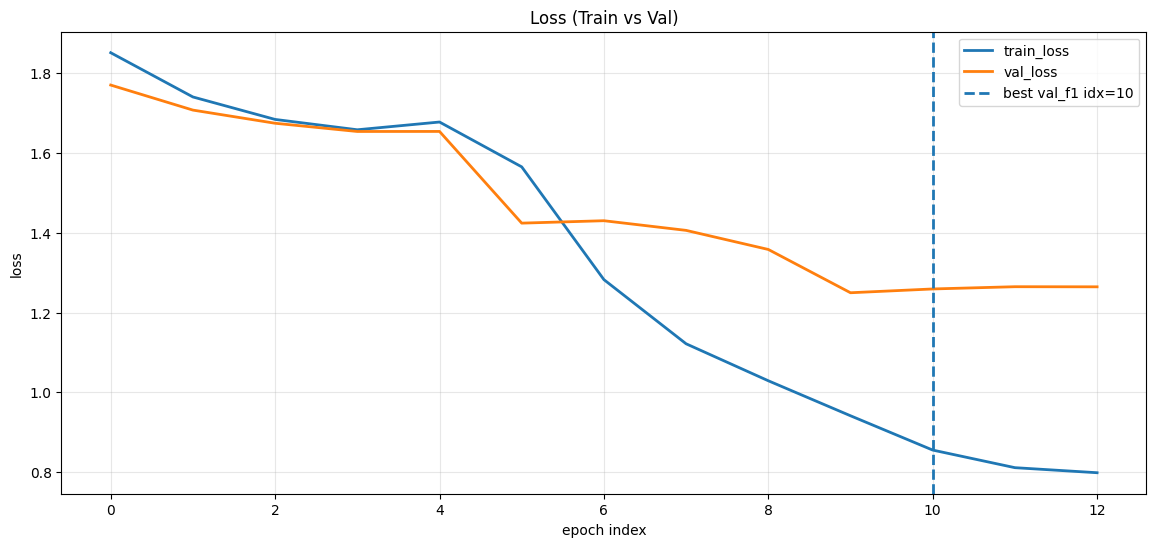

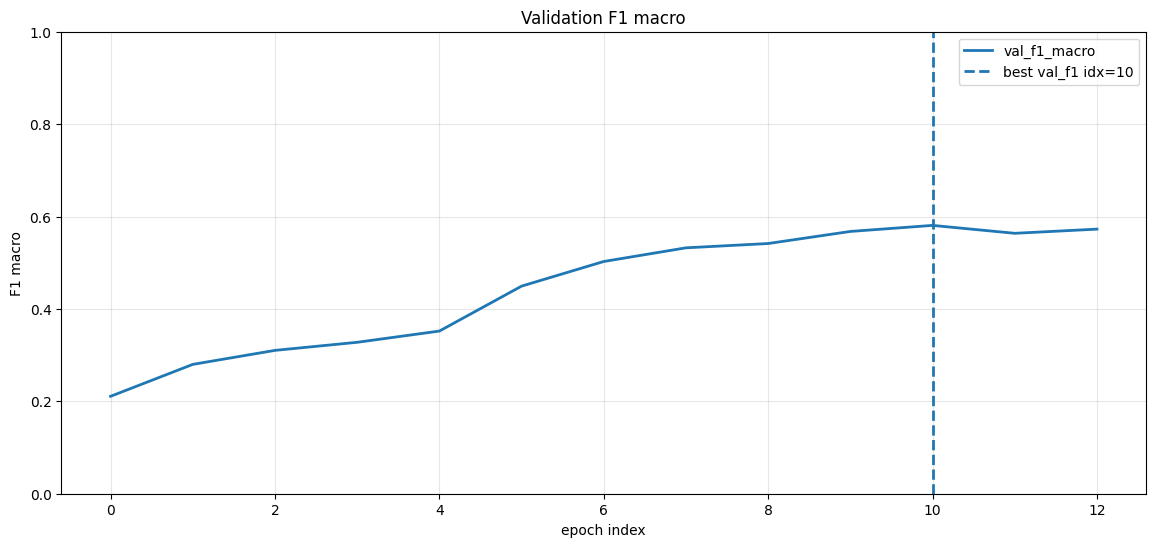

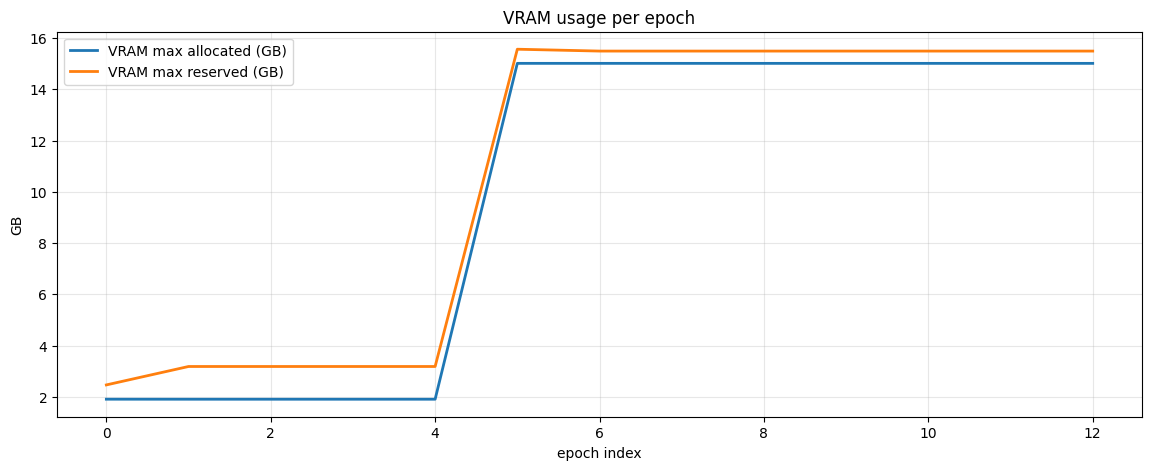

In [11]:
hist = pd.DataFrame(history)

best_idx = int(hist["val_f1m"].values.argmax())

plt.figure(figsize=(14, 6))
plt.plot(hist["train_loss"].values, label="train_loss", linewidth=2)
plt.plot(hist["val_loss"].values, label="val_loss", linewidth=2)
plt.axvline(best_idx, linestyle="--", linewidth=2, label=f"best val_f1 idx={best_idx}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Loss (Train vs Val)")
plt.xlabel("epoch index")
plt.ylabel("loss")
plt.show()

plt.figure(figsize=(14, 6))
plt.plot(hist["val_f1m"].values, label="val_f1_macro", linewidth=2)
plt.axvline(best_idx, linestyle="--", linewidth=2, label=f"best val_f1 idx={best_idx}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Validation F1 macro")
plt.xlabel("epoch index")
plt.ylabel("F1 macro")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(hist["vram_alloc_gb"].values, label="VRAM max allocated (GB)", linewidth=2)
plt.plot(hist["vram_resv_gb"].values, label="VRAM max reserved (GB)", linewidth=2)
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("VRAM usage per epoch")
plt.xlabel("epoch index")
plt.ylabel("GB")
plt.show()

## 11) Evaluación final en TEST

Cargamos el mejor modelo guardado y evaluamos en el conjunto de test (nunca visto).  
Mostramos:
- Loss, accuracy y F1-macro
- Classification report por clase
- Matriz de confusión para ver qué emociones se confunden más

TEST loss=1.5576 | acc=0.3782 | f1_macro=0.3720

Classification report:
              precision    recall  f1-score   support

       anger     0.5366    0.2418    0.3333        91
     disgust     0.4286    0.2283    0.2979        92
        fear     0.3067    0.5435    0.3922        92
         joy     0.4270    0.4130    0.4199        92
     neutral     0.3419    0.4396    0.3846        91
     sadness     0.4066    0.4022    0.4044        92

    accuracy                         0.3782       550
   macro avg     0.4079    0.3780    0.3720       550
weighted avg     0.4078    0.3782    0.3721       550



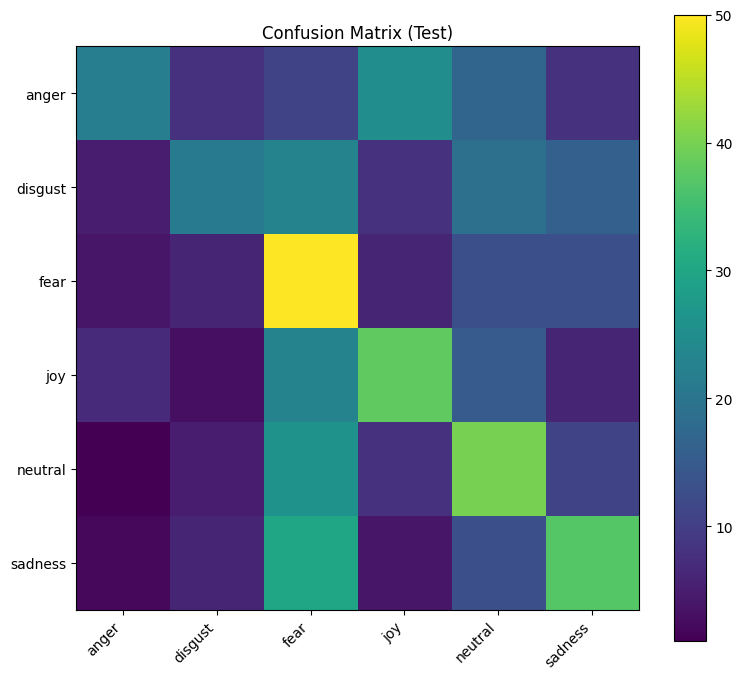

In [12]:
ckpt = torch.load(best_path, map_location="cpu")
model.load_state_dict(ckpt["model"])
model.to(device)

test_loss, test_acc, test_f1m, y_true, y_pred = evaluate(test_loader)
print(f"TEST loss={test_loss:.4f} | acc={test_acc:.4f} | f1_macro={test_f1m:.4f}")

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=labels, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,7))
plt.imshow(cm)
plt.title("Confusion Matrix (Test)")
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)
plt.colorbar()
plt.tight_layout()
plt.show()

## 12) Exportar modelo para inferencia

Guardamos el modelo y el `feature_extractor` en formato estándar de Transformers (`save_pretrained`).  
Esto permite cargarlo fácilmente después (por ejemplo en una app con Gradio o una demo).

In [13]:
EXPORT_DIR = os.path.join(OUT_DIR, "export_transformers")
os.makedirs(EXPORT_DIR, exist_ok=True)

model.save_pretrained(EXPORT_DIR)
feature_extractor.save_pretrained(EXPORT_DIR)

print("Exported to:", EXPORT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Exported to: runs_audio_ast_es_vram_max\export_transformers


## Notas rápidas
- Si te salta **CUDA OOM**, baja `BATCH_SIZE` a 4 y/o sube `GRAD_ACCUM`.
- Si algún audio da error al cargar, normalmente es un path roto: revisa `Missing files`.
- El warning del widget se arregla instalando `ipywidgets` y `jupyterlab_widgets` (celda 0).